# Combined Ground-State, Quantum Critical, and Quarkyonic Sound-Speed Analysis

This notebook groups the three already-working workflows in one place without changing
any of their internal logic:

- `ground_state_ab_k0`: ground-state fit for `a`, `b`, and `K_0`
- `quantum_tc_nc_scf`: quantum finite-temperature `T_c`, `n_c` with Fermi statistics and SCF
- `quarkyonic_sound_speed_vs2`: quarkyonic zero-temperature sound speed `v_s^2`

The original package folders and standalone notebooks inside this combined workspace remain untouched.


In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
workspace_dir = None

for candidate in [cwd, cwd.parent, cwd / "nuclear_matter_workflows"]:
    if (
        (candidate / "ground_state_ab_k0" / "src" / "ground_state_ab_k0").exists()
        and (candidate / "quantum_tc_nc_scf" / "src" / "quantum_tc_nc_scf").exists()
        and (candidate / "quarkyonic_sound_speed_vs2" / "src" / "quarkyonic_sound_speed_vs2").exists()
    ):
        workspace_dir = candidate
        break

if workspace_dir is None:
    raise RuntimeError("Could not locate the combined workflow folder.")

ground_state_src = workspace_dir / "ground_state_ab_k0" / "src"
quantum_src = workspace_dir / "quantum_tc_nc_scf" / "src"
quarkyonic_src = workspace_dir / "quarkyonic_sound_speed_vs2" / "src"
results_dir = workspace_dir / "results"
results_dir.mkdir(exist_ok=True)

for path in [str(ground_state_src), str(quantum_src), str(quarkyonic_src)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from ground_state_ab_k0 import DEFAULT_ALPHA_LIST as GS_ALPHA_LIST
from ground_state_ab_k0 import DEFAULT_C_LIST as GS_C_LIST
from ground_state_ab_k0.reporting import results_to_records
from ground_state_ab_k0.solver import compute_ground_state_point, compute_model_family

from quantum_tc_nc_scf import DEFAULT_ALPHA_LIST as Q_ALPHA_LIST
from quantum_tc_nc_scf import DEFAULT_C_LIST as Q_C_LIST
from quantum_tc_nc_scf.reporting import critical_results_to_records
from quantum_tc_nc_scf.solver import (
    QuantumCriticalSettings,
    compute_model_family_quantum,
    compute_quantum_critical_point,
)

from quarkyonic_sound_speed_vs2 import (
    QuarkyonicSettings,
    compute_selected_quarkyonic_curves,
    curve_to_records,
    summaries_to_records,
)


## Part I. Ground-State `a`, `b`, and $K_0$

In [9]:
ground_base_results = [
    compute_ground_state_point("vdw"),
    compute_ground_state_point("rks"),
    compute_ground_state_point("pr"),
]
ground_base_results = [result for result in ground_base_results if result is not None]

ground_clausius_results = compute_model_family("clausius", GS_C_LIST)
ground_dieterici_results = compute_model_family("dieterici", GS_ALPHA_LIST)


In [10]:
ground_base_df = pd.DataFrame(results_to_records(ground_base_results))
ground_clausius_df = pd.DataFrame(results_to_records(ground_clausius_results, parameter_name="c"))
ground_dieterici_df = pd.DataFrame(results_to_records(ground_dieterici_results, parameter_name="alpha"))

ground_combined_df = pd.concat([ground_base_df, ground_clausius_df, ground_dieterici_df], ignore_index=True)

ground_base_df.to_csv(results_dir / "combined_ground_state_base.csv", index=False)
ground_clausius_df.to_csv(results_dir / "combined_ground_state_clausius.csv", index=False)
ground_dieterici_df.to_csv(results_dir / "combined_ground_state_dieterici.csv", index=False)
ground_combined_df.to_csv(results_dir / "combined_ground_state_results.csv", index=False)

display(ground_base_df[["model", "a", "b", "K0", "binding", "n_sat", "p_sat"]])
display(ground_clausius_df[["parameter_value", "a", "b", "K0", "binding"]])
display(ground_dieterici_df[["parameter_value", "a", "b", "K0", "binding"]])


,model,a,b,K0,binding,n_sat,p_sat
0,vdw,328.923321,3.414020,762.538952,-16.0,0.16,6.942039e-07
1,rks,374.124601,2.934379,517.687257,-16.0,0.16,-9.225922e-07
2,pr,408.431529,2.817209,443.121464,-16.0,0.16,4.034110e-07


,parameter_value,a,b,K0,binding
0,0.000000,328.923321,3.414020,762.538952,-16.0
1,0.526667,345.853615,3.214111,648.158193,-16.0
2,1.053333,362.475851,3.017785,558.119138,-16.0
3,1.580000,378.823685,2.824791,485.945396,-16.0
4,2.106667,394.925039,2.634907,427.182075,-16.0
5,2.633333,410.803381,2.447939,378.683157,-16.0
6,3.160000,426.478658,2.263711,338.175575,-16.0
7,3.686667,441.967996,2.082068,303.983720,-16.0
8,4.213333,457.286227,1.902869,274.850293,-16.0
9,4.740000,472.446297,1.725987,249.816854,-16.0


,parameter_value,a,b,K0,binding
0,1.666667,102.651527,2.275872,249.894543,-16.0
1,1.703704,118.179413,2.448557,292.044939,-16.0
2,1.740741,135.579757,2.606026,337.735581,-16.0
3,1.777778,155.048773,2.750264,387.037979,-16.0
4,1.814815,176.801706,2.882917,440.022241,-16.0
5,1.851852,201.074567,3.005367,496.757174,-16.0
6,1.888889,228.126032,3.118778,557.310373,-16.0
7,1.925926,258.239500,3.224144,621.748301,-16.0
8,1.962963,291.725338,3.322314,690.136359,-16.0
9,2.000000,328.923321,3.414020,762.538952,-16.0


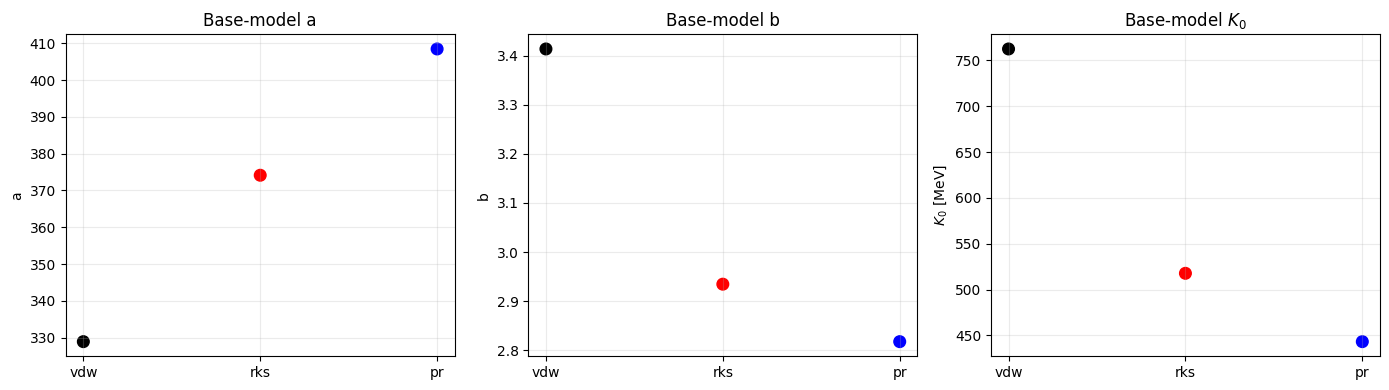

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(ground_base_df["model"], ground_base_df["a"], color=["black", "red", "blue"], s=70)
axes[0].set_title("Base-model a")
axes[0].set_ylabel("a")

axes[1].scatter(ground_base_df["model"], ground_base_df["b"], color=["black", "red", "blue"], s=70)
axes[1].set_title("Base-model b")
axes[1].set_ylabel("b")

axes[2].scatter(ground_base_df["model"], ground_base_df["K0"], color=["black", "red", "blue"], s=70)
axes[2].set_title(r"Base-model $K_0$")
axes[2].set_ylabel(r"$K_0$ [MeV]")

for axis in axes:
    axis.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(results_dir / "combined_ground_state_base_summary.png", dpi=300)
plt.show()


## Part II. Quantum $T_c$ and $n_c$ with Fermi Statistics and SCF

In [12]:
# Switch to QuantumCriticalSettings() for a denser run.
quantum_settings = QuantumCriticalSettings.quick()

quantum_base_results = [
    compute_quantum_critical_point("vdw", settings=quantum_settings),
    compute_quantum_critical_point("rks", settings=quantum_settings),
    compute_quantum_critical_point("pr", settings=quantum_settings),
]
quantum_base_results = [result for result in quantum_base_results if result is not None]

quantum_clausius_results = compute_model_family_quantum("clausius", Q_C_LIST, settings=quantum_settings)
quantum_dieterici_results = compute_model_family_quantum("dieterici", Q_ALPHA_LIST, settings=quantum_settings)


In [13]:
quantum_base_df = pd.DataFrame(critical_results_to_records(quantum_base_results))
quantum_clausius_df = pd.DataFrame(critical_results_to_records(quantum_clausius_results, parameter_name="c"))
quantum_dieterici_df = pd.DataFrame(critical_results_to_records(quantum_dieterici_results, parameter_name="alpha"))

quantum_combined_df = pd.concat([quantum_base_df, quantum_clausius_df, quantum_dieterici_df], ignore_index=True)

quantum_base_df.to_csv(results_dir / "combined_quantum_base.csv", index=False)
quantum_clausius_df.to_csv(results_dir / "combined_quantum_clausius.csv", index=False)
quantum_dieterici_df.to_csv(results_dir / "combined_quantum_dieterici.csv", index=False)
quantum_combined_df.to_csv(results_dir / "combined_quantum_results.csv", index=False)

display(quantum_base_df[["model", "a", "b", "K0", "Tc", "nc", "Pc", "score"]])
display(quantum_clausius_df[["parameter_value", "a", "b", "K0", "Tc", "nc"]])
display(quantum_dieterici_df[["parameter_value", "a", "b", "K0", "Tc", "nc"]])


,model,a,b,K0,Tc,nc,Pc,score
0,vdw,328.923321,3.414020,762.538952,19.714052,0.072417,0.526889,1.253540e-13
1,rks,374.124601,2.934379,517.687257,18.240018,0.064292,0.396777,6.948462e-14
2,pr,408.431529,2.817209,443.121464,17.141483,0.060724,0.331822,8.131122e-14


,parameter_value,a,b,K0,Tc,nc
0,0.000000,328.923321,3.414020,762.538952,19.714052,0.072417
1,0.526667,345.853615,3.214111,648.158193,19.134478,0.069021
2,1.053333,362.475851,3.017785,558.119138,18.621114,0.065914
3,1.580000,378.823685,2.824791,485.945396,18.162262,0.063061
4,2.106667,394.925039,2.634907,427.182075,17.748911,0.060434
5,2.633333,410.803381,2.447939,378.683157,17.374006,0.058006
6,3.160000,426.478658,2.263711,338.175575,17.031936,0.055758
7,3.686667,441.967996,2.082068,303.983720,16.718156,0.053670
8,4.213333,457.286227,1.902869,274.850293,16.428951,0.051725
9,4.740000,472.446297,1.725987,249.816854,16.161290,0.049911


,parameter_value,a,b,K0,Tc,nc
0,1.666667,102.651527,2.275872,249.894543,13.010131,0.058429
1,1.703704,118.179413,2.448557,292.044939,13.799753,0.060356
2,1.740741,135.579757,2.606026,337.735581,14.576705,0.062155
3,1.777778,155.048773,2.750264,387.037979,15.341697,0.063846
4,1.814815,176.801706,2.882917,440.022241,16.095411,0.065445
5,1.851852,201.074567,3.005367,496.757174,16.838453,0.066965
6,1.888889,228.126032,3.118778,557.310373,17.571363,0.068415
7,1.925926,258.239500,3.224144,621.748301,18.294641,0.069803
8,1.962963,291.725338,3.322314,690.136359,19.008734,0.071135
9,2.000000,328.923321,3.414020,762.538952,19.714052,0.072417


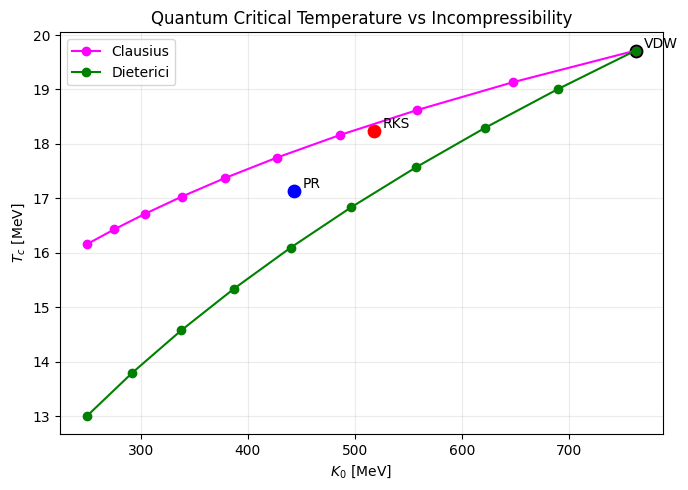

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

if not quantum_clausius_df.empty:
    ax.plot(quantum_clausius_df["K0"], quantum_clausius_df["Tc"], color="magenta", marker="o", label="Clausius")
if not quantum_dieterici_df.empty:
    ax.plot(quantum_dieterici_df["K0"], quantum_dieterici_df["Tc"], color="green", marker="o", label="Dieterici")

if not quantum_base_df.empty:
    color_map = {"vdw": "black", "rks": "red", "pr": "blue"}
    for _, row in quantum_base_df.iterrows():
        color = color_map.get(row["model"], "black")
        ax.scatter(row["K0"], row["Tc"], color=color, s=80)
        ax.text(row["K0"] + 8, row["Tc"] + 0.05, row["model"].upper())

ax.set_xlabel(r"$K_0$ [MeV]")
ax.set_ylabel(r"$T_c$ [MeV]")
ax.set_title("Quantum Critical Temperature vs Incompressibility")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(results_dir / "combined_quantum_tc_vs_k0.png", dpi=300)
plt.show()


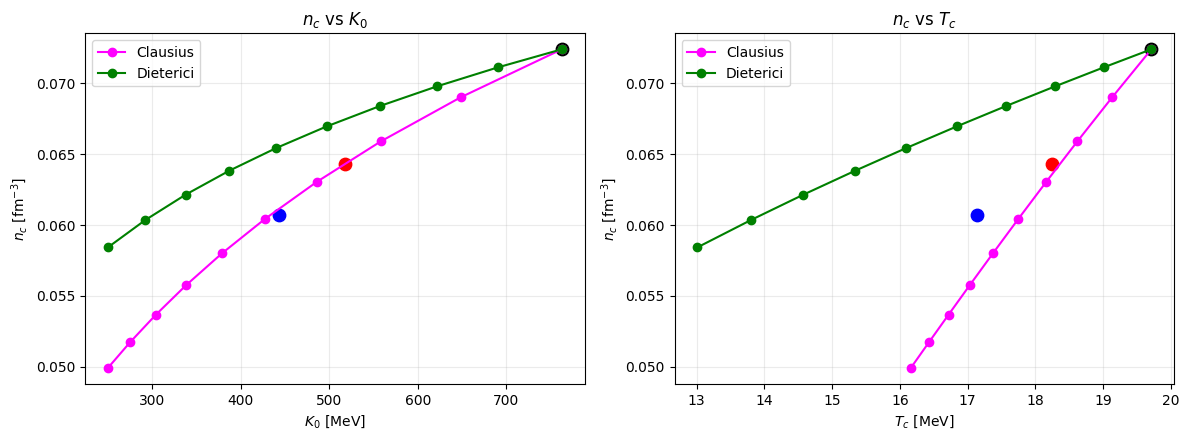

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

if not quantum_clausius_df.empty:
    axes[0].plot(quantum_clausius_df["K0"], quantum_clausius_df["nc"], color="magenta", marker="o", label="Clausius")
    axes[1].plot(quantum_clausius_df["Tc"], quantum_clausius_df["nc"], color="magenta", marker="o", label="Clausius")
if not quantum_dieterici_df.empty:
    axes[0].plot(quantum_dieterici_df["K0"], quantum_dieterici_df["nc"], color="green", marker="o", label="Dieterici")
    axes[1].plot(quantum_dieterici_df["Tc"], quantum_dieterici_df["nc"], color="green", marker="o", label="Dieterici")

if not quantum_base_df.empty:
    color_map = {"vdw": "black", "rks": "red", "pr": "blue"}
    for _, row in quantum_base_df.iterrows():
        color = color_map.get(row["model"], "black")
        axes[0].scatter(row["K0"], row["nc"], color=color, s=80)
        axes[1].scatter(row["Tc"], row["nc"], color=color, s=80)

axes[0].set_xlabel(r"$K_0$ [MeV]")
axes[0].set_ylabel(r"$n_c$ [fm$^{-3}$]")
axes[0].set_title(r"$n_c$ vs $K_0$")

axes[1].set_xlabel(r"$T_c$ [MeV]")
axes[1].set_ylabel(r"$n_c$ [fm$^{-3}$]")
axes[1].set_title(r"$n_c$ vs $T_c$")

for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()

fig.tight_layout()
fig.savefig(results_dir / "combined_quantum_nc_summary.png", dpi=300)
plt.show()


## Part III. Quarkyonic Sound Speed $v_s^2$

This section reuses the standalone `quarkyonic_sound_speed_vs2` workflow exactly as-is.
At fixed baryon density $n_B$, the total quarkyonic energy density is minimized with
respect to the quark fraction $f_Q$, and the minimum-energy branch is then used to reconstruct

$$
\mu_B = rac{darepsilon}{dn_B},
\qquad
P = n_B \mu_B - arepsilon,
\qquad
v_s^2 = rac{dP/dn_B}{darepsilon/dn_B}.
$$


In [16]:
# Switch to QuarkyonicSettings() for the denser default run.
quarkyonic_settings = QuarkyonicSettings.quick()
quarkyonic_curves = compute_selected_quarkyonic_curves(settings=quarkyonic_settings)


In [17]:
quarkyonic_summary_df = pd.DataFrame(summaries_to_records(quarkyonic_curves))
quarkyonic_curve_df = pd.DataFrame(
    [row for curve in quarkyonic_curves for row in curve_to_records(curve)]
)

quarkyonic_summary_df.to_csv(results_dir / "combined_quarkyonic_sound_speed_summary.csv", index=False)
quarkyonic_curve_df.to_csv(results_dir / "combined_quarkyonic_sound_speed_curves.csv", index=False)

display(quarkyonic_summary_df[["model", "parameter_value", "a", "b", "K0", "vs2_max", "n_tr_over_n0"]])


,model,parameter_value,a,b,K0,vs2_max,n_tr_over_n0
0,vdw,NaN,328.923321,3.414020,762.538952,0.789621,1.475525
1,rks,NaN,374.124601,2.934379,517.687257,0.844737,1.727273
2,pr,NaN,408.431529,2.817209,443.121464,0.873137,1.799201
3,dieterici,1.666667,102.651527,2.275872,249.894543,1.007754,2.194806
4,clausius,4.740000,472.446297,1.725987,249.816854,1.126599,2.878122


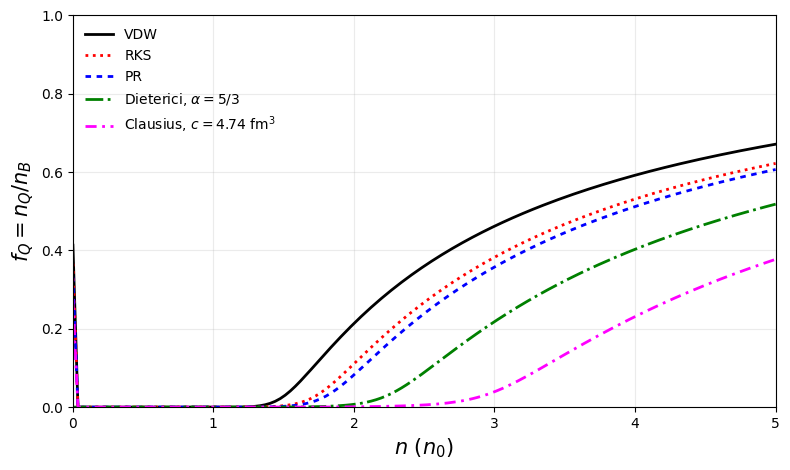

In [18]:
color_map = {
    "vdw": "black",
    "rks": "red",
    "pr": "blue",
    "dieterici": "green",
    "clausius": "magenta",
}

label_map = {
    "vdw": "VDW",
    "rks": "RKS",
    "pr": "PR",
    "dieterici": r"Dieterici, $\alpha = 5/3$",
    "clausius": r"Clausius, $c = 4.74\ \mathrm{fm}^3$",
}

linestyle_map = {
    "vdw": "-",
    "rks": ":",
    "pr": (0, (2, 2)),
    "dieterici": "-.",
    "clausius": (0, (4, 2, 1, 2)),
}

fig, ax = plt.subplots(figsize=(8, 4.8))

for curve in quarkyonic_curves:
    ax.plot(
        curve.n_over_n0,
        curve.quark_fraction,
        color=color_map[curve.model],
        lw=2.0,
        ls=linestyle_map[curve.model],
        label=label_map[curve.model],
    )

ax.set_xlabel(r"$n$ ($n_0$)", fontsize=15)
ax.set_ylabel(r"$f_Q = n_Q/n_B$", fontsize=15)
ax.set_xlim(0.0, 5.0)
ax.set_ylim(0.0, 1.0)
ax.legend(frameon=False, fontsize=10, loc="upper left")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(results_dir / "combined_quarkyonic_fraction_selected.png", dpi=300)
plt.show()


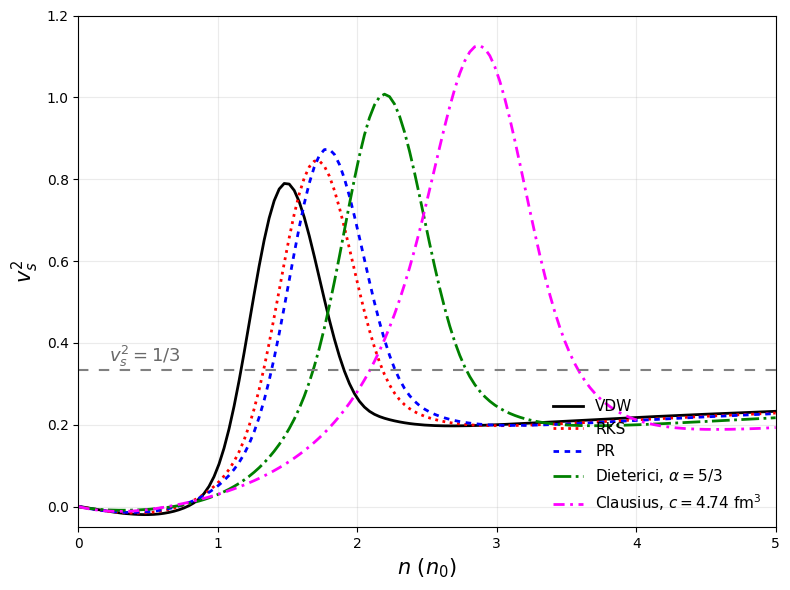

In [19]:
color_map = {
    "vdw": "black",
    "rks": "red",
    "pr": "blue",
    "dieterici": "green",
    "clausius": "magenta",
}

label_map = {
    "vdw": "VDW",
    "rks": "RKS",
    "pr": "PR",
    "dieterici": r"Dieterici, $\alpha = 5/3$",
    "clausius": r"Clausius, $c = 4.74\ \mathrm{fm}^3$",
}

linestyle_map = {
    "vdw": "-",
    "rks": ":",
    "pr": (0, (2, 2)),
    "dieterici": "-.",
    "clausius": (0, (4, 2, 1, 2)),
}

fig, ax = plt.subplots(figsize=(8, 6))

for curve in quarkyonic_curves:
    ax.plot(
        curve.n_over_n0,
        curve.vs2,
        color=color_map[curve.model],
        lw=2.0,
        ls=linestyle_map[curve.model],
        label=label_map[curve.model],
    )

ax.axhline(1.0 / 3.0, color="gray", lw=1.5, ls=(0, (5, 5)))
ax.text(0.22, 1.0 / 3.0 + 0.02, r"$v_s^2 = 1/3$", color="dimgray", fontsize=13)

ax.set_xlabel(r"$n$ ($n_0$)", fontsize=15)
ax.set_ylabel(r"$v_s^2$", fontsize=15)
ax.set_xlim(0.0, 5.0)
ax.set_ylim(-0.05, 1.2)
ax.legend(frameon=False, fontsize=11, loc="lower right")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(results_dir / "combined_quarkyonic_sound_speed_selected.png", dpi=300)
plt.show()
